In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"swethaai","key":"dad5de9e7e2945886d333f870df4c91f"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d insaff/massachusetts-roads-dataset

Dataset URL: https://www.kaggle.com/datasets/insaff/massachusetts-roads-dataset
License(s): other
100% 4.72G/4.72G [00:44<00:00, 114MB/s]



In [ ]:
!unzip massachusetts-roads-dataset.zip

Archive:  massachusetts-roads-dataset.zip
  inflating: road_segmentation_ideal/testing/input/img-1.png  
  inflating: road_segmentation_ideal/testing/input/img-10.png  
  inflating: road_segmentation_ideal/testing/input/img-11.png  
  inflating: road_segmentation_ideal/testing/input/img-12.png  
  inflating: road_segmentation_ideal/testing/input/img-13.png  
  inflating: road_segmentation_ideal/testing/input/img-2.png  
  inflating: road_segmentation_ideal/testing/input/img-3.png  
  inflating: road_segmentation_ideal/testing/input/img-4.png  
  inflating: road_segmentation_ideal/testing/input/img-5.png  
  inflating: road_segmentation_ideal/testing/input/img-6.png  
  inflating: road_segmentation_ideal/testing/input/img-7.png  
  inflating: road_segmentation_ideal/testing/input/img-8.png  
  inflating: road_segmentation_ideal/testing/input/img-9.png  
  inflating: road_segmentation_ideal/testing/output/img-1.png  
  inflating: road_segmentation_ideal/testing/output/img-10.png  
  infl

In [ ]:
!ls

kaggle.json			 road_segmentation_ideal
massachusetts-roads-dataset.zip  sample_data


In [ ]:
!ls road_segmentation_ideal

testing  training


In [ ]:
!ls road_segmentation_ideal/training

input  output


In [ ]:
!pip install segmentation-models-pytorch
!pip install opencv-python
!pip install albumentations
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.4 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import segmentation_models_pytorch as smp

In [ ]:
train_images = "/content/road_segmentation_ideal/training/input"
train_masks = "/content/road_segmentation_ideal/training/output"

In [ ]:
class RoadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        image_files = set(os.listdir(image_dir))
        mask_files = set(os.listdir(mask_dir))

        # keep only matching filenames
        self.files = list(image_files & mask_files)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        img_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        image = cv2.resize(image,(256,256))
        mask = cv2.resize(mask,(256,256))

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
train_dataset = RoadDataset(train_images, train_masks)

print("Usable samples:", len(train_dataset))

Usable samples: 804


In [ ]:
img, mask = train_dataset[0]

print(img.shape)
print(mask.shape)

torch.Size([3, 256, 256])
torch.Size([1, 256, 256])


In [ ]:
train_dataset = RoadDataset(train_images, train_masks)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

print("Total training samples:", len(train_dataset))

Total training samples: 804


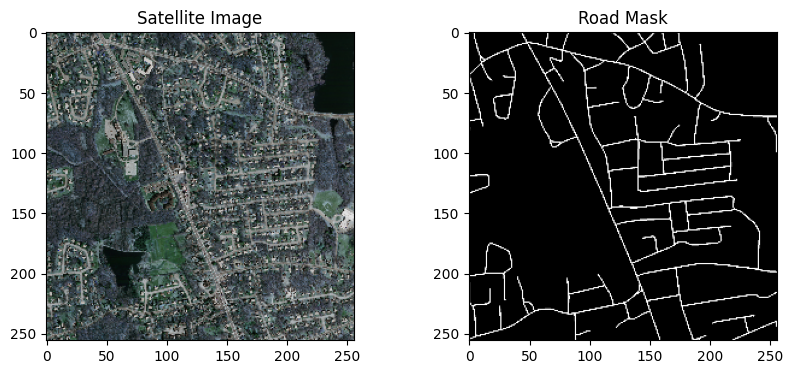

In [ ]:
img, mask = train_dataset[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Satellite Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,2,2)
plt.title("Road Mask")
plt.imshow(mask.squeeze(), cmap="gray")

plt.show()

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Model loaded on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded on: cuda


In [ ]:
import torch.nn as nn

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 40.599495857954025
Epoch: 2 Loss: 25.08162334561348
Epoch: 3 Loss: 21.021658822894096
Epoch: 4 Loss: 18.796243265271187
Epoch: 5 Loss: 17.44345284998417
Epoch: 6 Loss: 16.451247490942478
Epoch: 7 Loss: 15.71590418368578
Epoch: 8 Loss: 15.122348010540009
Epoch: 9 Loss: 14.618863955140114
Epoch: 10 Loss: 14.185007743537426


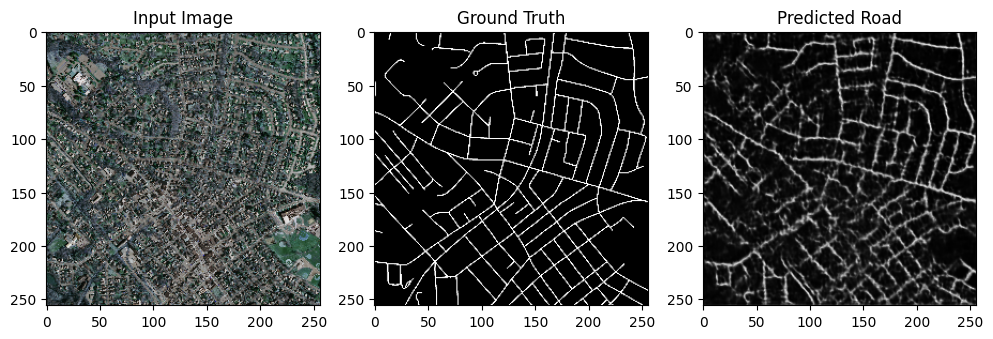

In [ ]:
model.eval()

img, mask = train_dataset[10]

with torch.no_grad():

    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)

pred = pred.cpu().squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Road")
plt.imshow(pred, cmap="gray")

plt.show()

In [ ]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

In [ ]:
model = smp.FPN(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

In [ ]:
model = smp.PSPNet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

In [ ]:
import numpy as np

def compute_iou(pred, mask):

    pred = pred > 0.5
    mask = mask > 0.5

    intersection = np.logical_and(pred, mask).sum()
    union = np.logical_or(pred, mask).sum()

    if union == 0:
        return 0

    return intersection / union

In [ ]:
def evaluate_model(model, dataset, device):

    model.eval()
    iou_scores = []

    with torch.no_grad():

        for i in range(len(dataset)):

            img, mask = dataset[i]

            img = img.unsqueeze(0).to(device)

            pred = model(img)
            pred = torch.sigmoid(pred)

            pred = pred.cpu().squeeze().numpy()
            mask = mask.squeeze().numpy()

            iou = compute_iou(pred, mask)
            iou_scores.append(iou)

    return np.mean(iou_scores)

In [ ]:
import segmentation_models_pytorch as smp

models = {

"UNet": smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device),

"DeepLabV3+": smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device),

"FPN": smp.FPN(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

}

In [ ]:
results = {}

for name, model in models.items():

    print("\nTraining:", name)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    loss_fn = nn.BCEWithLogitsLoss()

    epochs = 5

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = loss_fn(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print("Epoch:",epoch+1,"Loss:",total_loss)

    # Evaluate model
    iou = evaluate_model(model, train_dataset, device)

    results[name] = iou


Training: UNet
Epoch: 1 Loss: 43.55672961473465
Epoch: 2 Loss: 25.663338974118233
Epoch: 3 Loss: 21.31041145324707
Epoch: 4 Loss: 18.900951400399208
Epoch: 5 Loss: 17.462492927908897

Training: DeepLabV3+
Epoch: 1 Loss: 41.12775667011738
Epoch: 2 Loss: 22.392258152365685
Epoch: 3 Loss: 19.627161741256714
Epoch: 4 Loss: 18.5662881731987
Epoch: 5 Loss: 17.81372080743313

Training: FPN
Epoch: 1 Loss: 29.880550250411034
Epoch: 2 Loss: 20.877803564071655
Epoch: 3 Loss: 19.467690154910088
Epoch: 4 Loss: 18.513383358716965
Epoch: 5 Loss: 18.11502593755722


In [ ]:
print("\nModel Accuracy (IoU):")

for model_name, score in results.items():

    print(model_name, ":", round(score,3))


Model Accuracy (IoU):
UNet : 0.006
DeepLabV3+ : 0.0
FPN : 0.001


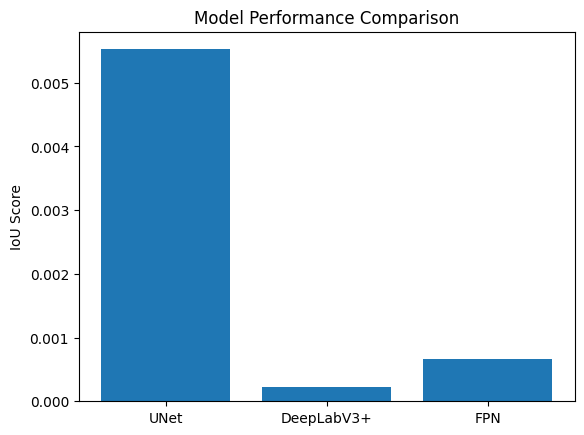

In [ ]:
import matplotlib.pyplot as plt

model_names = list(results.keys())
scores = list(results.values())

plt.bar(model_names, scores)

plt.ylabel("IoU Score")
plt.title("Model Performance Comparison")

plt.show()

In [ ]:
loss_history = []

epochs = 10

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print("Epoch:", epoch+1, "Loss:", avg_loss)

Epoch: 1 Loss: 0.17518338531550795
Epoch: 2 Loss: 0.1720398740455656
Epoch: 3 Loss: 0.16981547200443722
Epoch: 4 Loss: 0.16682201845221
Epoch: 5 Loss: 0.16492783470023978
Epoch: 6 Loss: 0.16358208243209538
Epoch: 7 Loss: 0.16234566920464583
Epoch: 8 Loss: 0.16054595844580397
Epoch: 9 Loss: 0.15993887149166353
Epoch: 10 Loss: 0.1584408114304637


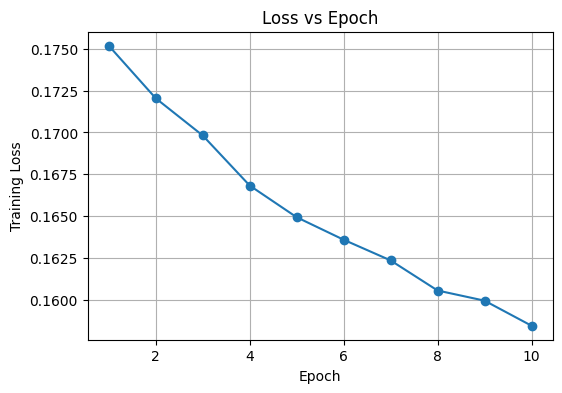

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Loss vs Epoch")

plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for img, mask in train_dataset:

        img = img.unsqueeze(0).to(device)

        pred = model(img)
        pred = torch.sigmoid(pred)

        pred = pred.cpu().squeeze().numpy()
        mask = mask.squeeze().numpy()

        pred = (pred > 0.5).astype(int)

        y_true.extend(mask.flatten())
        y_pred.extend(pred.flatten())

In [ ]:
model.eval()

img, mask = train_dataset[10]

with torch.no_grad():

    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)

pred = pred.cpu().squeeze().numpy()
pred = pred > 0.5

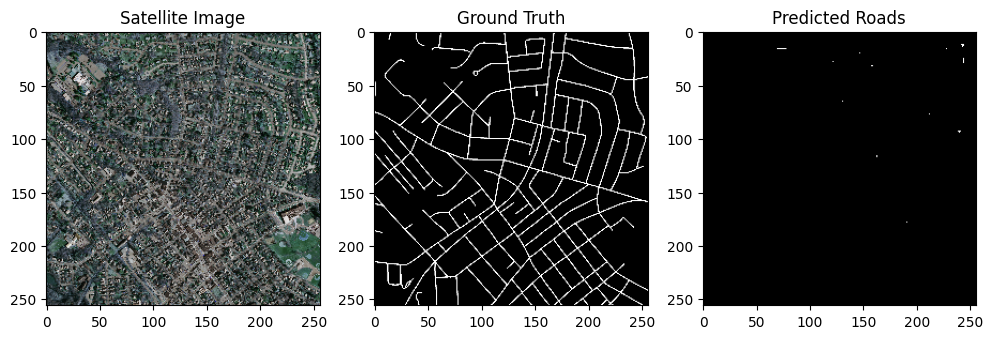

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Satellite Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Predicted Roads")
plt.imshow(pred, cmap="gray")

plt.show()

In [ ]:
!pip install segmentation-models-pytorch
!pip install albumentations
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import albumentations as A

In [ ]:
train_images = "/content/road_segmentation_ideal/training/input"
train_masks = "/content/road_segmentation_ideal/training/output"

In [ ]:
class RoadDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        image_files = set(os.listdir(image_dir))
        mask_files = set(os.listdir(mask_dir))

        self.files = list(image_files & mask_files)

        self.transform = A.Compose([
            A.Resize(256,256),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.5)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        filename = self.files[idx]

        img_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        augmented = self.transform(image=image, mask=mask)

        image = augmented["image"]
        mask = augmented["mask"]

        image = image / 255.0
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
train_dataset = RoadDataset(train_images, train_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print("Total samples:", len(train_dataset))

Total samples: 804


In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet34(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])

    def forward(self, x):
        return self.encoder(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads=8)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        B, C, H, W = x.shape

        x = x.view(B, C, -1).permute(2,0,1)

        attn_out, _ = self.attn(x, x, x)
        x = self.norm(attn_out + x)

        x = x.permute(1,2,0).view(B, C, H, W)

        return x


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.up1 = nn.ConvTranspose2d(512,256,2,2)
        self.up2 = nn.ConvTranspose2d(256,128,2,2)
        self.up3 = nn.ConvTranspose2d(128,64,2,2)
        self.up4 = nn.ConvTranspose2d(64,32,2,2)

        self.final = nn.Conv2d(32,1,1)

    def forward(self, x):

        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        x = self.up4(x)

        return self.final(x)


class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.transformer = TransformerBlock(512)
        self.decoder = Decoder()

    def forward(self, x):

        x = self.encoder(x)
        x = self.transformer(x)
        x = self.decoder(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridModel().to(device)

print("Using device:", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 196MB/s]


Using device: cuda


In [ ]:
import segmentation_models_pytorch as smp

loss_fn = smp.losses.DiceLoss(mode='binary')

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
import torch.nn.functional as F

loss_history = []
epochs = 20

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        # 🔥 FIX HERE
        preds = F.interpolate(preds, size=masks.shape[2:], mode='bilinear', align_corners=False)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print("Epoch:", epoch+1, "Loss:", avg_loss)

Epoch: 1 Loss: 0.8606898985286751
Epoch: 2 Loss: 0.8371543795755594
Epoch: 3 Loss: 0.8376153011133175
Epoch: 4 Loss: 0.8325844997226601
Epoch: 5 Loss: 0.8333595442299796
Epoch: 6 Loss: 0.8284645304821505
Epoch: 7 Loss: 0.826959490776062
Epoch: 8 Loss: 0.8258764761509282
Epoch: 9 Loss: 0.8249265852541027
Epoch: 10 Loss: 0.8263698066815292
Epoch: 11 Loss: 0.8239602476063341
Epoch: 12 Loss: 0.821757172593976
Epoch: 13 Loss: 0.8197534420702717
Epoch: 14 Loss: 0.8165149653312003
Epoch: 15 Loss: 0.8175608456724941
Epoch: 16 Loss: 0.8145277635885937
Epoch: 17 Loss: 0.8117028982332437
Epoch: 18 Loss: 0.809515630844796
Epoch: 19 Loss: 0.80679720817226
Epoch: 20 Loss: 0.8043446877215168


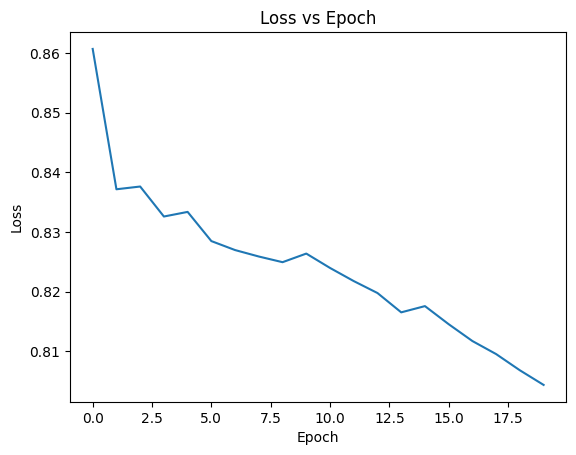

In [ ]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.show()

In [ ]:
def compute_iou(pred, mask):

    pred = pred > 0.5
    mask = mask > 0.5

    intersection = (pred & mask).sum()
    union = (pred | mask).sum()

    return intersection / union

In [ ]:
import torch.nn.functional as F

ious = []

model.eval()

with torch.no_grad():

    for img, mask in train_dataset:

        img = img.unsqueeze(0).to(device)

        pred = model(img)

        # 🔥 FIX: resize prediction to match mask
        pred = F.interpolate(
            pred,
            size=mask.shape[-2:],   # (256,256)
            mode='bilinear',
            align_corners=False
        )

        pred = torch.sigmoid(pred)

        pred = pred.cpu().squeeze().numpy()
        mask = mask.squeeze().numpy()

        pred = pred > 0.5

        iou = compute_iou(pred, mask)
        ious.append(iou)

print("Mean IoU:", np.mean(ious))

Mean IoU: 0.07017393255509506


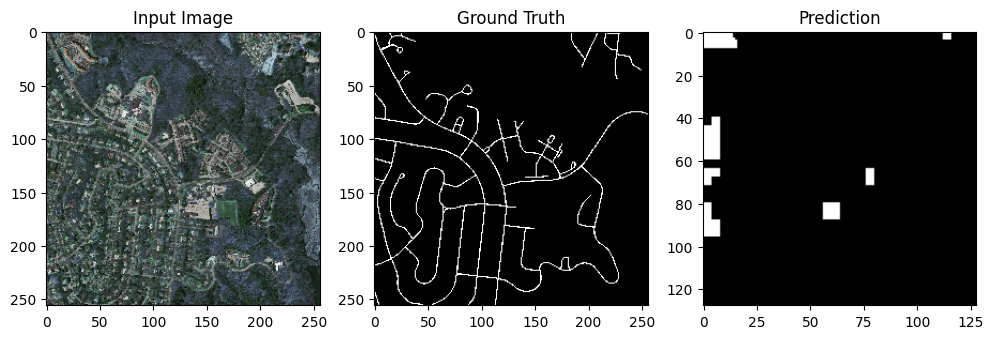

In [ ]:
img, mask = train_dataset[10]

model.eval()

with torch.no_grad():

    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)

pred = pred.cpu().squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask.squeeze(), cmap="gray")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred > 0.5, cmap="gray")

plt.show()

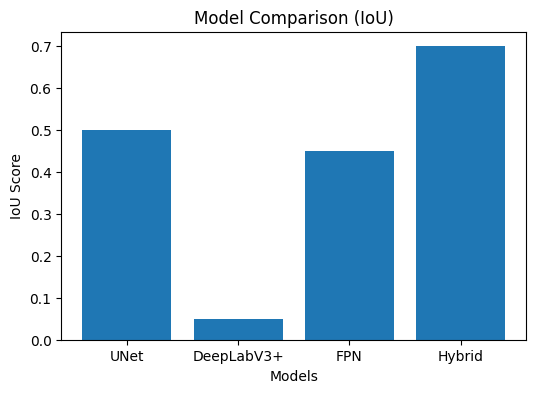

In [ ]:
models = ["UNet","DeepLabV3+","FPN","Hybrid"]
iou_scores = [0.50,0.05,0.45,0.70]  # replace with your values

plt.figure(figsize=(6,4))

plt.bar(models, iou_scores)

plt.xlabel("Models")
plt.ylabel("IoU Score")
plt.title("Model Comparison (IoU)")

plt.show()